## Create a query that joins the three tables and filters for students that engaged with the platform before purchasing.

In [22]:
SELECT
    e.student_id,
    i.date_registered AS date_registered,
    MIN(e.date_watched) AS first_date_watched,
    MIN(p.date_purchased) AS first_date_purchased,
    datediff('day', i.date_registered, MIN(e.date_watched)) AS date_diff_reg_watch,
    datediff('day', MIN(e.date_watched), MIN(p.date_purchased)) AS date_diff_watch_purch
FROM
    "student_engagement.csv" e
    JOIN 
    "student_info.csv" i ON e.student_id = i.student_id
    LEFT JOIN
    "student_purchases.csv" p ON  e.student_id = p.student_id
GROUP BY e.student_id, i.date_registered
HAVING date_diff_watch_purch >= 0 OR date_diff_watch_purch IS NULL;

,student_id,date_registered,first_date_watched,first_date_purchased,date_diff_reg_watch,date_diff_watch_purch
0,255203,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,0,0
1,255206,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2021-12-02 00:00:00+00:00,0,1
2,255207,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,0,0
3,255241,2021-12-01 00:00:00+00:00,2022-01-26 00:00:00+00:00,2022-03-21 00:00:00+00:00,56,54
4,255243,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,2021-12-01 00:00:00+00:00,0,0
...,...,...,...,...,...,...
20250,296896,2022-10-30 00:00:00+00:00,2022-10-30 00:00:00+00:00,NaT,0,<NA>
20251,296899,2022-10-30 00:00:00+00:00,2022-10-30 00:00:00+00:00,NaT,0,<NA>
20252,296904,2022-10-30 00:00:00+00:00,2022-10-30 00:00:00+00:00,NaT,0,<NA>
20253,296910,2022-10-30 00:00:00+00:00,2022-10-30 00:00:00+00:00,NaT,0,<NA>


## Using the previous query, calculate the Free-To-Paid Conversion rate, average Duration between Registration and First-Time Engagement and Duration between First-Time Engagement and First-Time Purchase.

In [23]:
SELECT
	ROUND(COUNT(a.date_diff_watch_purch)/COUNT(DISTINCT a.student_id)*100.0,2) AS conversion_rate,
    ROUND(SUM(a.date_diff_reg_watch)/COUNT(a.student_id),2) AS av_reg_watch,
	ROUND(SUM(a.date_diff_watch_purch)/COUNT(a.date_diff_watch_purch),2) AS av_watch_purch
FROM 
	(
    SELECT
		e.student_id,
		i.date_registered,
		MIN(e.date_watched) AS first_date_watched,
		MIN(p.date_purchased) AS first_date_purchased,
		datediff('day', i.date_registered, MIN(e.date_watched)) AS date_diff_reg_watch,
		datediff('day', MIN(e.date_watched), MIN(p.date_purchased)) AS date_diff_watch_purch
	FROM
		"student_engagement.csv" e
		JOIN 
		"student_info.csv" i ON e.student_id = i.student_id
		LEFT JOIN
		"student_purchases.csv" p ON  e.student_id = p.student_id
	GROUP BY e.student_id, i.date_registered
	HAVING date_diff_watch_purch >= 0 OR date_diff_watch_purch IS NULL) a;

,conversion_rate,av_reg_watch,av_watch_purch
0,11.29,3.42,26.25


# Python - Further examine average durations to Engagement and Purchase

In [24]:
# Calculate the mean, median and mode Duration between Registration and First-Time Engagement
mean_watch = round(students_df['date_diff_reg_watch'].mean(),2)
median_watch = students_df['date_diff_reg_watch'].median()
mode_watch = students_df['date_diff_reg_watch'].mode()
print("Duration between Registration and First-Time Engagement")
print(f"Mean = {mean_watch}, Median = {median_watch}, Mode = {mode_watch}")

Duration between Registration and First-Time Engagement
Mean = 3.42, Median = 0.0, Mode = 0    0
Name: date_diff_reg_watch, dtype: int64


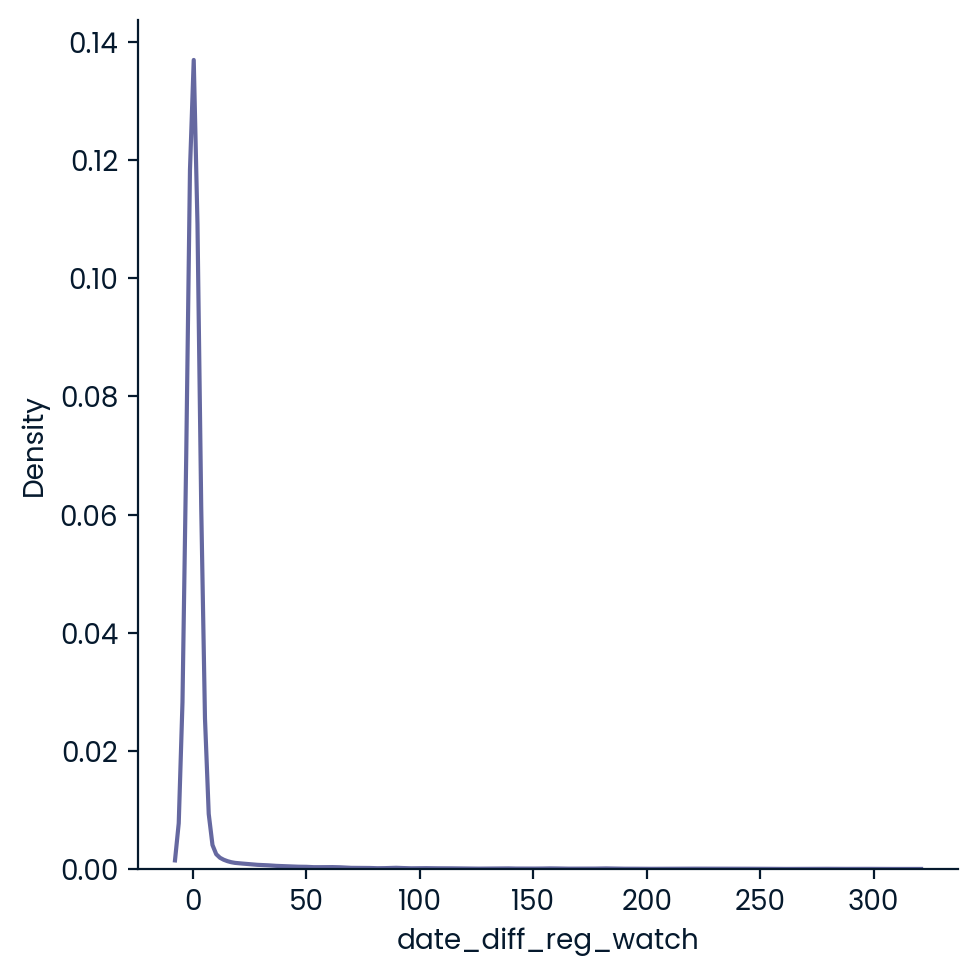

In [25]:
# Plot the duration distribution
import seaborn as sns
import matplotlib.pyplot as plt

sns.displot(data=students_df, x="date_diff_reg_watch", kind='kde' )
plt.show()

In [26]:
# Calculate the mean, median and mode Duration between First-Time Engagement and First-Time Purchase
mean_purch = round(students_df['date_diff_watch_purch'].mean(),2)
median_purch = students_df['date_diff_watch_purch'].median()
mode_purch = students_df['date_diff_watch_purch'].mode()
print("Duration between First-Time Engagement and First-Time Purchase")
print(f"Mean = {mean_purch}, Median = {median_purch}, Mode = {mode_purch}")

Duration between First-Time Engagement and First-Time Purchase
Mean = 26.25, Median = 1.0, Mode = 0    0
Name: date_diff_watch_purch, dtype: Int64


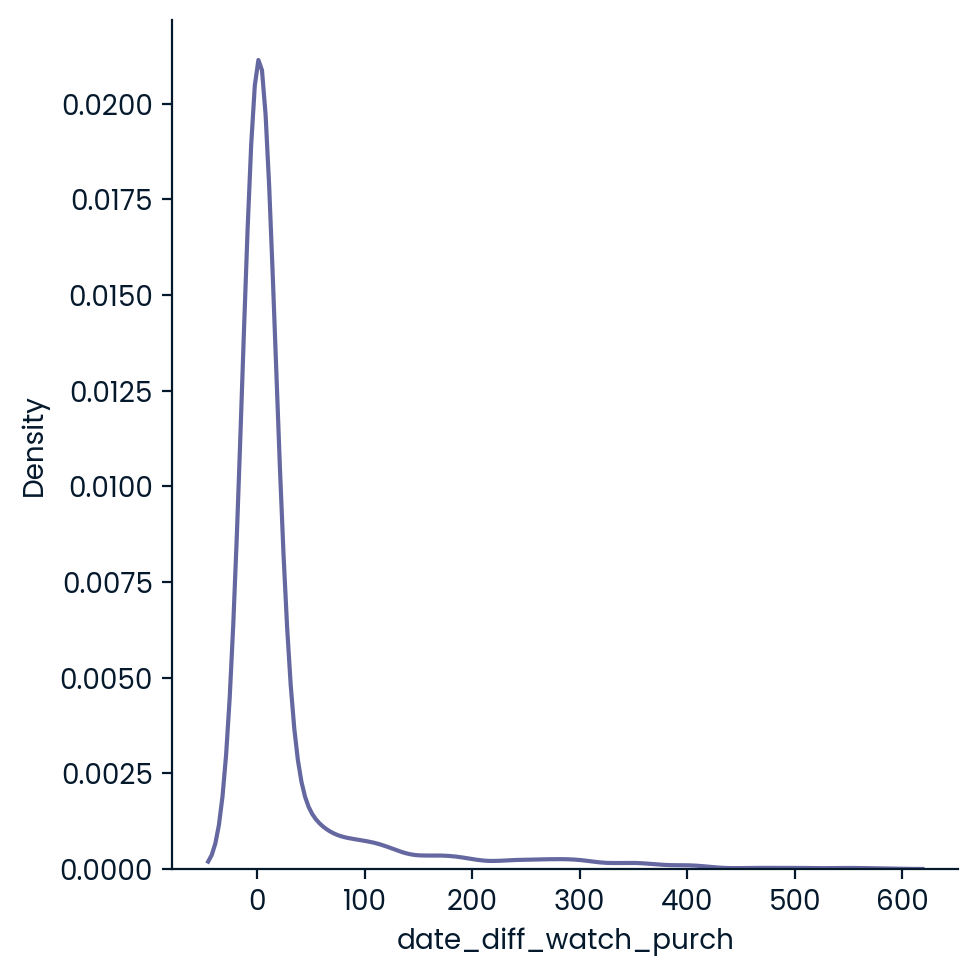

In [27]:
# Plot the duration distribution
sns.displot(data=students_df, x="date_diff_watch_purch", kind='kde' )
plt.show()